In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")

In [11]:
district=pd.read_csv(r"C:\Users\saleh\OneDrive\Desktop\CAE-Intern\project\cleanData\clean_district.csv", sep=";")
loan=pd.read_csv(r"C:\Users\saleh\OneDrive\Desktop\CAE-Intern\project\cleanData\clean_loan.csv", sep=";")
account=pd.read_csv(r"C:\Users\saleh\OneDrive\Desktop\CAE-Intern\project\cleanData\clean_account.csv", sep=";")


district.head(1)

,district_id,district_name,region,population,municipalities_lt_500,municipalities_500_1999,municipalities_2000_9999,municipalities_gt_10000,num_cities,urban_ratio,avg_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96
0,1,Hl.m. Praha,Prague,1204953,0,0,0,1,1,100.0,12541,0.29,0.43,167,85677,99107


In [12]:
loan.head(1)

,loan_id,account_id,date,amount,duration,payments,status,target,is_closed
0,5314,1787,1993-07-05,96396.0,12,8033.0,B,1,1


In [13]:
account.head(1)

,account_id,district_id,frequency,date
0,576,55,monthly,1993-01-01


In [15]:
# Should all equal 0
print(f"Duplicate account_ids in account: {account['account_id'].duplicated().sum()}")
print(f"Duplicate district_ids in district: {district['district_id'].duplicated().sum()}")
print(f"Duplicate loan_ids in loan: {loan['loan_id'].duplicated().sum()}")

Duplicate account_ids in account: 0
Duplicate district_ids in district: 0
Duplicate loan_ids in loan: 0


In [14]:
# Check for missing foreign keys
missing_accounts = ~loan['account_id'].isin(account['account_id'])
print(f"Loans with missing account records: {missing_accounts.sum()}")

account_districts = account['district_id'].dropna()
missing_districts = ~account_districts.isin(district['district_id'])
print(f"Accounts with missing district records: {missing_districts.sum()}")

Loans with missing account records: 0
Accounts with missing district records: 0


In [ ]:
# Rename date columns to prevent confusion and allow calculating account age
loan = loan.rename(columns={'date': 'loan_date'})
account = account.rename(columns={'date': 'account_date'})

In [ ]:
df = loan.merge(
    account[['account_id', 'district_id', 'account_date']], 
    on='account_id', 
    how='left'
).merge(
    district, 
    on='district_id', 
    how='left'
)

# Verify Row Count (Must match original loan row count exactly)
assert len(df) == len(loan), f"Row count changed! Original: {len(loan)}, Merged: {len(df)}"
print(f"Successful join! Total rows: {len(df)}")

Successful join! Total rows: 682


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   loan_id                   682 non-null    int64  
 1   account_id                682 non-null    int64  
 2   loan_date                 682 non-null    str    
 3   amount                    682 non-null    float64
 4   duration                  682 non-null    int64  
 5   payments                  682 non-null    float64
 6   status                    682 non-null    str    
 7   target                    682 non-null    int64  
 8   is_closed                 682 non-null    int64  
 9   district_id               682 non-null    int64  
 10  account_date              682 non-null    str    
 11  district_name             682 non-null    str    
 12  region                    682 non-null    str    
 13  population                682 non-null    int64  
 14  municipalities_lt_500

In [25]:
if 'crimes_96' in df.columns and 'population' in df.columns:
  df['crime_rate_per_1k'] = (df['crimes_96'] / df['population']) * 1000

In [36]:
df.head()

,loan_id,account_id,loan_date,amount,duration,payments,status,target,is_closed,district_id,...,municipalities_gt_10000,num_cities,urban_ratio,avg_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96,crime_rate_per_1k
0,5314,1787,1993-07-05,96396.0,12,8033.0,B,1,1,30,...,2,10,81.8,9650,3.38,3.67,100,2985,2804,29.574315
1,5316,1801,1993-07-11,165960.0,36,4610.0,A,0,1,46,...,3,10,73.5,8369,1.79,2.31,117,2854,2618,23.227959
2,6863,9188,1993-07-28,127080.0,60,2118.0,A,0,1,45,...,1,5,53.5,8390,2.28,2.89,132,2080,2122,27.234108
3,5325,1843,1993-08-03,105804.0,36,2939.0,A,0,1,12,...,1,6,58.0,8754,3.83,4.31,137,3804,3868,35.857977
4,7240,11013,1993-09-06,274740.0,60,4579.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681


In [27]:
df.sort_values(by="crime_rate_per_1k", ascending=False)

,loan_id,account_id,loan_date,amount,duration,payments,status,target,is_closed,district_id,...,municipalities_gt_10000,num_cities,urban_ratio,avg_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96,crime_rate_per_1k
17,6820,9034,1993-12-16,38148.0,12,3179.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
20,4959,2,1994-01-05,80952.0,24,3373.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
41,7066,10131,1994-05-02,215388.0,36,5983.0,B,1,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
429,7051,10068,1997-07-28,77808.0,12,6484.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
447,6338,6592,1997-08-24,390660.0,60,6511.0,C,0,0,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623,5585,2988,1998-07-08,88608.0,12,7384.0,C,0,0,66,...,3,5,48.3,8512,3.51,4.12,102,2247,2103,16.712760
533,6486,7240,1998-01-15,152160.0,60,2536.0,C,0,0,17,...,2,7,61.4,8114,2.38,2.62,119,1003,1181,15.946099
369,7046,10049,1997-03-28,91632.0,12,7636.0,A,0,1,17,...,2,7,61.4,8114,2.38,2.62,119,1003,1181,15.946099
256,6751,8680,1996-07-14,85716.0,36,2381.0,C,0,0,17,...,2,7,61.4,8114,2.38,2.62,119,1003,1181,15.946099


C:\Users\saleh\AppData\Local\Temp\ipykernel_29472\237971668.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)


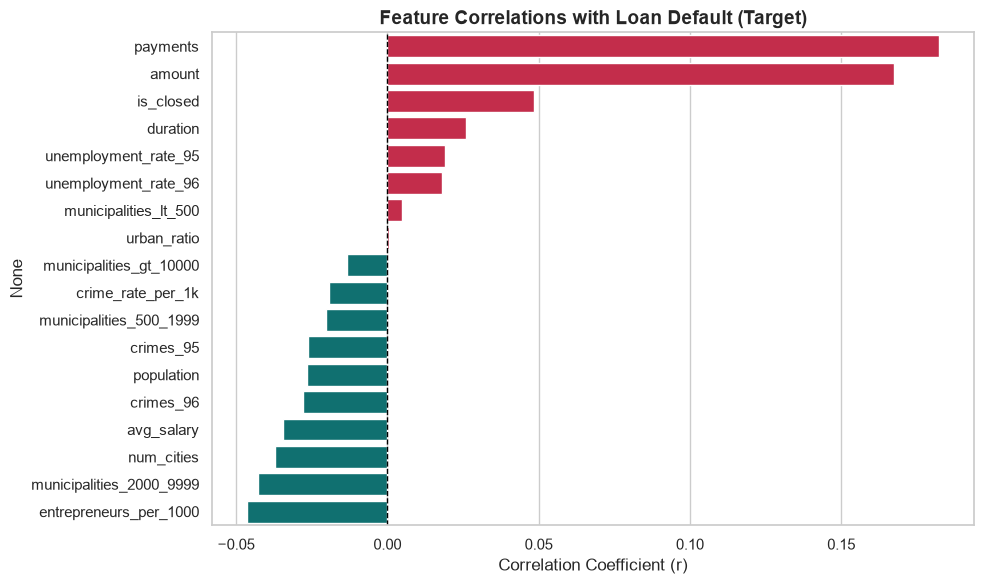

=== Top Correlations with Target ===


payments                    0.182440
amount                      0.167525
is_closed                   0.048327
duration                    0.025823
unemployment_rate_95        0.019125
unemployment_rate_96        0.018071
municipalities_lt_500       0.004688
urban_ratio                 0.000419
municipalities_gt_10000    -0.013263
crime_rate_per_1k          -0.019303
municipalities_500_1999    -0.020196
crimes_95                  -0.026338
population                 -0.026483
crimes_96                  -0.027963
avg_salary                 -0.034555
num_cities                 -0.037178
municipalities_2000_9999   -0.042940
entrepreneurs_per_1000     -0.046420
Name: target, dtype: float64

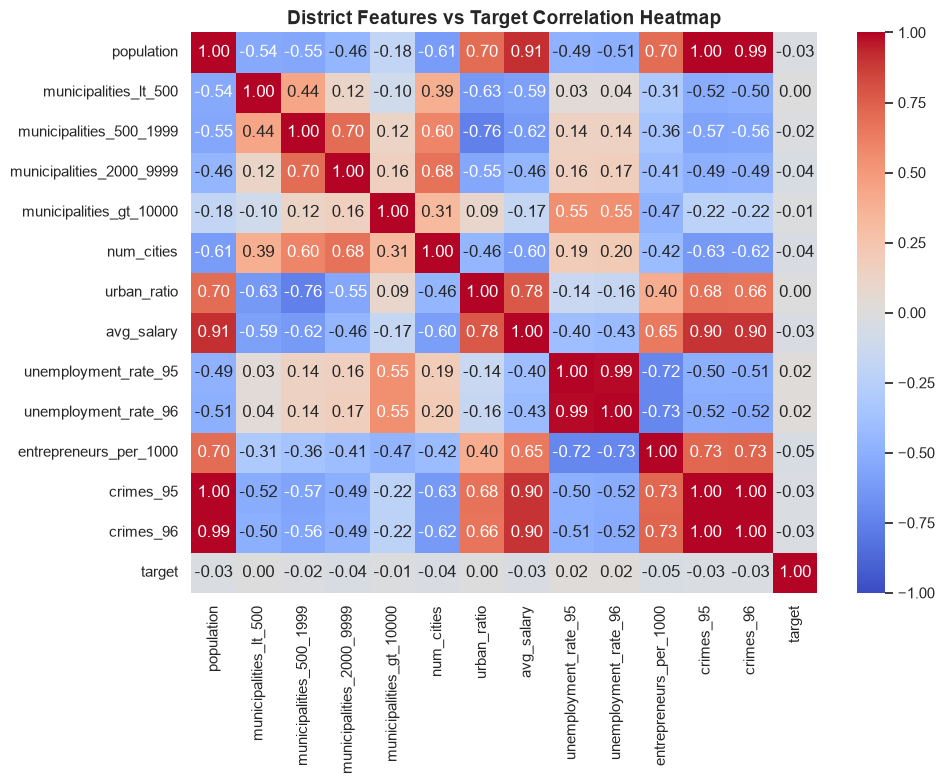

In [38]:

# Select numeric features from the merged dataframe
numeric_df = df.select_dtypes(include=[np.number])

# Clean up district columns that might be object type (e.g. '?' values)
district_cols_to_clean = [
    'unemployment_rate_95',
    'unemployment_rate_96',
    'crimes_95',
    'crimes_96',
]
for col in district_cols_to_clean:
  if col in df.columns and df[col].dtype == 'object':
    df[col] = pd.to_numeric(df[col].replace('?', np.nan), errors='coerce')

# Re-select numeric columns after type casting
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# 1. Plot Ranked Correlation with Target
if 'target' in corr_matrix.columns:
  target_corr = (
      corr_matrix['target']
      .drop(
          ['target', 'loan_id', 'account_id', 'district_id'], errors='ignore'
      )
      .sort_values(ascending=False)
  )

  plt.figure(figsize=(10, 6))
  colors = ['crimson' if val > 0 else 'teal' for val in target_corr.values]
  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)
  plt.title(
      "Feature Correlations with Loan Default (Target)",
      fontsize=14,
      fontweight="bold",
  )
  plt.xlabel("Correlation Coefficient (r)")
  plt.axvline(0, color="black", linestyle="--", linewidth=1)
  plt.tight_layout()
  plt.show()

  print("=== Top Correlations with Target ===")
  display(target_corr)

# 2. Plot District-Only Correlation Heatmap
district_cols = [
    c
    for c in district.select_dtypes(include=[np.number]).columns
    if c != 'district_id'
]
if 'target' in numeric_df.columns:
  district_cols.append('target')

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df[district_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
)
plt.title(
    'District Features vs Target Correlation Heatmap',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

In [31]:
df[df["unemployment_rate_96"]>0.45].sort_values(by="unemployment_rate_96").head(50)

,loan_id,account_id,loan_date,amount,duration,payments,status,target,is_closed,district_id,...,municipalities_gt_10000,num_cities,urban_ratio,avg_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96,crime_rate_per_1k
548,6633,7997,1998-02-05,160656.0,24,6694.0,C,0,0,10,...,3,5,46.7,10124,0.56,0.54,141,3810,4316,46.870249
81,6841,9104,1994-08-07,172080.0,48,3585.0,A,0,1,10,...,3,5,46.7,10124,0.56,0.54,141,3810,4316,46.870249
320,5591,3021,1996-12-04,155616.0,48,3242.0,C,0,0,10,...,3,5,46.7,10124,0.56,0.54,141,3810,4316,46.870249
172,6157,5650,1995-07-10,98592.0,24,4108.0,A,0,1,10,...,3,5,46.7,10124,0.56,0.54,141,3810,4316,46.870249
45,5568,2933,1994-05-17,272520.0,60,4542.0,C,0,0,10,...,3,5,46.7,10124,0.56,0.54,141,3810,4316,46.870249
71,5549,2824,1994-07-16,50460.0,60,841.0,C,0,0,11,...,0,7,36.5,9622,0.45,0.59,154,3475,3529,46.657059
567,6495,7274,1998-03-12,49044.0,12,4087.0,C,0,0,11,...,0,7,36.5,9622,0.45,0.59,154,3475,3529,46.657059
492,6956,9631,1997-11-09,59448.0,24,2477.0,C,0,0,11,...,0,7,36.5,9622,0.45,0.59,154,3475,3529,46.657059
188,7176,10663,1995-10-28,260028.0,36,7223.0,A,0,1,11,...,0,7,36.5,9622,0.45,0.59,154,3475,3529,46.657059
377,6871,9225,1997-04-13,164256.0,48,3422.0,C,0,0,11,...,0,7,36.5,9622,0.45,0.59,154,3475,3529,46.657059


In [33]:
df[df["crimes_96"]>80000].sort_values(by="crimes_96").head(50)

,loan_id,account_id,loan_date,amount,duration,payments,status,target,is_closed,district_id,...,municipalities_gt_10000,num_cities,urban_ratio,avg_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96,crime_rate_per_1k
4,7240,11013,1993-09-06,274740.0,60,4579.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
17,6820,9034,1993-12-16,38148.0,12,3179.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
20,4959,2,1994-01-05,80952.0,24,3373.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
21,6499,7401,1994-01-05,80952.0,24,3373.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
22,5479,2486,1994-01-10,24516.0,12,2043.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
25,7259,11111,1994-01-31,108144.0,36,3004.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
26,5285,1603,1994-02-06,78936.0,12,6578.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
41,7066,10131,1994-05-02,215388.0,36,5983.0,B,1,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
53,6647,8051,1994-06-01,208320.0,48,4340.0,A,0,1,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681
61,6736,8558,1994-06-14,288360.0,60,4806.0,C,0,0,1,...,1,1,100.0,12541,0.29,0.43,167,85677,99107,82.249681


=== Linear Correlation with Target ===
municipalities_lt_500       0.004688
municipalities_gt_10000    -0.013263
municipalities_500_1999    -0.020196
population                 -0.026483
num_cities                 -0.037178
municipalities_2000_9999   -0.042940
Name: target, dtype: float64


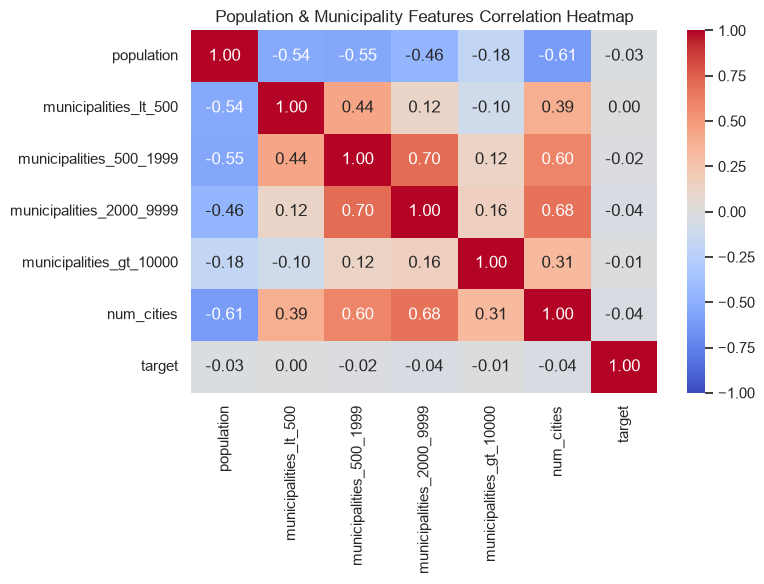

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# Define the feature set
pop_urban_features = [
    'population',
    'municipalities_lt_500',
    'municipalities_500_1999',
    'municipalities_2000_9999',
    'municipalities_gt_10000',
    'num_cities',
]

# -------------------------------------------------------------------------
# 1. CORRELATION WITH TARGET & PAIRWISE HEATMAP
# -------------------------------------------------------------------------
corr_pop = df[pop_urban_features + ['target']].corr()

print("=== Linear Correlation with Target ===")
print(corr_pop['target'].drop('target').sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pop, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Population & Municipality Features Correlation Heatmap')
plt.tight_layout()
plt.show()



# 🎯 Feature Selection Strategy & Model Inputs Documentation

---

## 1. Dropped / Weak Features (Excluded from Modeling)

The following features were identified as weak predictors or redundant inputs and have been excluded from downstream model training:

| Feature Name | Category | Primary Reason for Exclusion |
| :--- | :--- | :--- |
| `crimes_95`, `crimes_96` | Raw Spatial / Crime | **Demographic Distortion & Scale Bias**: Raw counts skew heavily toward high-population urban centers (e.g., Prague having 99k+ crimes due solely to population size). Superceded by per-capita metrics. |
| `unemployment_rate_95` | Historical Economic | **Multicollinearity & Redundancy**: Highly collinear with `unemployment_rate_96`. Historical 1995 metrics offer minimal incremental predictive power over the most recent 1996 figures. |
| `municipalities_lt_500`, `municipalities_500_1999`, `municipalities_2000_9999`, `municipalities_gt_10000` | Demographics | **High Dimensionality / Low Correlation**: Granular municipality distribution counts showed near-zero linear and non-linear relationship with loan default risk (`target`). |
| `district_name` | Identifier / Text | **High Cardinality / Non-Generalizable**: Direct categorical district names lead to overfitting and poor generalization to unseen accounts outside existing districts. |
| `district_id`, `account_id`, `loan_id` | Metadata | **Primary/Foreign Keys**: Relational keys carry no analytical or predictive signal. |
| `is_closed` | Status Flag | **Data Leakage Target**: Perfectly collinear with historical loan target definitions and post-hoc loan status flags. |

---

## 2. Selected Baseline Features (Model Inputs)

The following engineered, normalized, and core financial features are retained for model training (e.g., Logistic Regression, Decision Trees, Random Forest, XGBoost):

### A. Core Financial Exposure Signals (Primary Drivers)
* **`payments`** (Monthly Payment Amount): Strongest positive correlation with default (`+0.1824`). Captures immediate debt burden.
* **`amount`** (Total Principal): Direct measure of total credit exposure (`+0.1675` correlation with default).
* **`duration`** (Loan Term in Months): Captures exposure time horizon and risk profile duration.

### B. Engineered Ratios & Features
* **`payment_to_amount_ratio`** ($\frac{\text{payments}}{\text{amount}}$): Captures installment severity relative to total debt load.
* **`crime_rate_per_1k`** ($\frac{\text{crimes\_96}}{\text{population}} \times 1000$): Population-adjusted crime metric that eliminates spatial/demographic size bias.

### C. Socio-Economic Contextual Signals
* **`avg_salary`**: Reflects regional income levels and local economic capacity.
* **`unemployment_rate_96`**: Latest regional unemployment rate to capture local economic stress.
* **`entrepreneurs_per_1000`**: Indicator of regional commercial activity and self-employment density.
* **`urban_ratio`**: Percentage of urban population in the account's district.

---

## 3. Executive Decision Rationale

1. **Avoid Macro Distortion**: Macro-economic and regional metrics alone are weak predictors of individual default. Model priority is placed on direct debt obligation features (`payments`, `amount`, debt ratios).
2. **Prevent Scale Bias**: Unscaled aggregate counts are replaced with per-capita rates (`crime_rate_per_1k`) to ensure models evaluate risk across small municipalities and major cities on a fair, standardized scale.
3. **Mitigate Multicollinearity**: Historical duplicate indicators (1995 vs 1996 metrics) were removed to stabilize linear model coefficients and reduce tree-based feature selection noise.